# ERNIE-RNA exercise notebook: computing RNA embeddings

This notebook is a small, self-contained exercise workbook using **ERNIE-RNA**, the structure-enhanced RNA language model from:

> Yin, W., Zhang, Z., He, L. *et al.* "ERNIE-RNA: an RNA language model with structure-enhanced representations." *Nature Communications* **16**, 10076 (2025). https://www.nature.com/articles/s41467-025-64972-0

This notebook:
1. Installs and loads the ERNIE-RNA model.
2. Runs it on a handful of example RNA sequences.
3. Extracts per-token and pooled (CLS + mean) embeddings.
4. Does a couple of sanity checks / visualizations (pairwise similarity, 2D projection) so you can see the embeddings are meaningful.

Your task is to extend the notebook to: 
1. Repeat the embedding visualization for real RNA sequences
2. Create a predictor that can predict class for input RNA sequences
3. (Optional) Explore seconday structure visualization for RNA sequences

## 0. Setup

Requires Python ≥ 3.9. Installs `multimolecule` (which pulls in `torch` and `transformers` as dependencies).

In [ ]:
# Uncomment to install (works in uv and can be adapted to Colab / a fresh venv )
# !uv pip install -q multimolecule torch scikit-learn matplotlib
# !uv pip install --upgrade 'transformers<5.16'

In [2]:
import torch
import numpy as np

import multimolecule
from multimolecule import RnaTokenizer, ErnieRnaModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

/opt/miniconda3/envs/rnallms/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0917 10:07:46.851000 71743 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.


Using device: cpu


## 1. Load the pre-trained model

This downloads `multimolecule/ernierna` from the Hugging Face Hub the first time it's run (~86M parameters, base pre-trained model, no fine-tuning).

In [3]:
MODEL_NAME = "multimolecule/ernierna"

tokenizer = RnaTokenizer.from_pretrained(MODEL_NAME)
model = ErnieRnaModel.from_pretrained(MODEL_NAME)
model = model.to(device)
model.eval()

print(model.config)

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 6434.35it/s]
[transformers] ErnieRnaModel LOAD REPORT from: multimolecule/ernierna
Key                                 | Status     |  | 
------------------------------------+------------+--+-
lm_head.transform.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias                        | UNEXPECTED |  | 
lm_head.transform.layer_norm.weight | UNEXPECTED |  | 
lm_head.transform.dense.weight      | UNEXPECTED |  | 
lm_head.transform.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ErnieRnaConfig {
  "add_cross_attention": false,
  "architectures": [
    "ErnieRnaForPreTraining"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": 1,
  "dtype": "float32",
  "eos_token_id": 2,
  "head": null,
  "hidden_act": "gelu",
  "hidden_dropout": 0.1,
  "hidden_size": 768,
  "id2label": null,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": null,
  "layer_norm_eps": 1e-05,
  "lm_head": {
    "act": null,
    "bias": true,
    "dropout": 0.0,
    "hidden_size": null,
    "layer_norm_eps": 1e-05,
    "loss_weight": null,
    "num_labels": 28,
    "output_name": null,
    "transform": "nonlinear",
    "transform_act": "gelu"
  },
  "mask_token_id": 4,
  "max_position_embeddings": 1026,
  "model_type": "ernierna",
  "null_token_id": 5,
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "num_labels": 1,
  "output_attention_biases": false,
  "pad_token_id": 0,
  "pairwise_alpha": 0.8,
  "position_embedding_type": "sinusoidal",
  "

## 2. Example data

15 toy non-coding RNA sequences across 4 families, so the embeddings below have something to (hopefully) cluster by. Feel free to replace these with your own sequences (they should use standard RNA letters: A, U, G, C; the tokenizer will also accept T and convert it to U automatically).

- **hairpin** (3): short stem–loop sequences. Each is built as `stem + loop + reverse_complement(stem)`, so the two ends are complementary and could base-pair into a hairpin — `hairpin_2` and `hairpin_3` use the common `GAAA`/`UUCG` tetraloop motifs.
- **trna** (3): tRNA-like sequences (~73–76 nt), the classic length/composition for a cloverleaf-structured tRNA.
- **utr** (3): short 5' UTR-like sequences, each containing a Kozak-like context (`...CCACC-AUG-G...`) around an AUG start codon.
- **random** (6): sequences with no particular structure — some are simple repeats (GC-only, AU-only, dinucleotide/tetranucleotide repeats) and some are more arbitrary, as a contrast group.

These are illustrative toy sequences designed to have the right length/compositional flavor of each family — not curated from a real structural database — so treat any clustering you see as a plausibility check on the embeddings, not a rigorous benchmark.

In [4]:
example_sequences = {
    # --- hairpin-like: stem + loop + reverse-complement(stem) ---
    "hairpin_1": "GGGCGCUUAAAGCGCCC",
    "hairpin_2": "GGGCCGAAAGGCCC",
    "hairpin_3": "GCGGCUUCGGCCGC",

    # --- tRNA-like: ~73-76 nt, cloverleaf-style composition ---
    "trna_1": "GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGGUCCUGUGUUCGAUCCACAGAAUUCGCACCA",
    "trna_2": "GGGGCUAUAGCUCAGCUGGGAGAGCGCUUGCAUGGCAUGCAAGAGGUCAGCGGUUCGAUCCCGCUUAGCUCCACCA",
    "trna_3": "GCCCGGCUAGCUCAGUCGGUAGAGCAUGGGACUUUUAAUCCCAGGGUCGUGGGUUCGAGCCCCACGUUGGGCG",

    # --- 5' UTR-like: short, with a Kozak-like context around an AUG ---
    "utr_1": "GGGAGACCGGCCUUAGCCAUGGGCUUA",
    "utr_2": "GGCACUUGCAGUCUUCAGCUUCCCACCAUGGCGACU",
    "utr_3": "CUCGCUCUUCUCCCUCCUCCACCAUGGCGGCCGCUU",

    # --- random / unstructured, for contrast ---
    "random_1": "AUGCUAGCUAGCUAGCUAGCUAGCGAUCGAUCGUAGCUA",
    "random_2": "CCCCAAAAUUUUGGGGCCCCAAAAUUUUGGGG",
    "random_3": "GCGCGCGCGCGCGCGCGCGCGCGCGCGC",
    "random_4": "AUAUAUAUAUAUAUAUAUAUAUAUAUAU",
    "random_5": "AGCUAGCUAGCUAGCUAGCUAGCUAGCUAGCU",
    "random_6": "GAUCGAUCGAUCGAUCGAUCGAUCGAUC",
}

# Family label for each sequence, used later to colour the PCA plot
sequence_family = {name: name.rsplit("_", 1)[0] for name in example_sequences}

for name, seq in example_sequences.items():
    print(f"{name:10s} [{sequence_family[name]:8s}] (len={len(seq):3d}): {seq}")

hairpin_1  [hairpin ] (len= 17): GGGCGCUUAAAGCGCCC
hairpin_2  [hairpin ] (len= 14): GGGCCGAAAGGCCC
hairpin_3  [hairpin ] (len= 14): GCGGCUUCGGCCGC
trna_1     [trna    ] (len= 76): GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGGUCCUGUGUUCGAUCCACAGAAUUCGCACCA
trna_2     [trna    ] (len= 76): GGGGCUAUAGCUCAGCUGGGAGAGCGCUUGCAUGGCAUGCAAGAGGUCAGCGGUUCGAUCCCGCUUAGCUCCACCA
trna_3     [trna    ] (len= 73): GCCCGGCUAGCUCAGUCGGUAGAGCAUGGGACUUUUAAUCCCAGGGUCGUGGGUUCGAGCCCCACGUUGGGCG
utr_1      [utr     ] (len= 27): GGGAGACCGGCCUUAGCCAUGGGCUUA
utr_2      [utr     ] (len= 36): GGCACUUGCAGUCUUCAGCUUCCCACCAUGGCGACU
utr_3      [utr     ] (len= 36): CUCGCUCUUCUCCCUCCUCCACCAUGGCGGCCGCUU
random_1   [random  ] (len= 39): AUGCUAGCUAGCUAGCUAGCUAGCGAUCGAUCGUAGCUA
random_2   [random  ] (len= 32): CCCCAAAAUUUUGGGGCCCCAAAAUUUUGGGG
random_3   [random  ] (len= 28): GCGCGCGCGCGCGCGCGCGCGCGCGCGC
random_4   [random  ] (len= 28): AUAUAUAUAUAUAUAUAUAUAUAUAUAU
random_5   [random  ] (len= 32): AGCUAGCUAGCUAGCUAGCUAGCUAGCUA

## 3. Compute embeddings

ERNIE-RNA is a BERT-style encoder: it produces one 768-dimensional vector per token, including special `<cls>` and `<eos>` tokens added by the tokenizer. We'll extract:

- **Per-token embeddings** (`last_hidden_state`): shape `(seq_len, 768)`.
- **CLS embedding**: the first token's vector, often used as a whole-sequence summary.
- **Mean-pooled embedding**: the average of the token embeddings (excluding the special `<cls>`/`<eos>` tokens), another common whole-sequence representation.

In [6]:
@torch.no_grad()
def embed_sequence(seq: str):
    """Return per-token, CLS, and mean-pooled embeddings for a single RNA sequence."""
    inputs = tokenizer(seq, return_tensors="pt").to(device)
    outputs = model(**inputs)

    token_embeddings = outputs.last_hidden_state.squeeze(0).cpu().numpy()  # (seq_len, 768)

    cls_embedding = token_embeddings[0]  # <cls> token is prepended by the tokenizer

    # Exclude <cls> (index 0) and <eos> (last index) from the mean pool
    mean_embedding = token_embeddings[1:-1].mean(axis=0)

    return token_embeddings, cls_embedding, mean_embedding

results = {}

for name, seq in example_sequences.items():
    tok_emb, cls_emb, mean_emb = embed_sequence(seq)
    results[name] = {
        "sequence": seq,
        "token_embeddings": tok_emb,
        "cls_embedding": cls_emb,
        "mean_embedding": mean_emb,
    }
    print(f"{name:16s}: token_embeddings {tok_emb.shape}, cls {cls_emb.shape}, mean {mean_emb.shape}")

hairpin_1       : token_embeddings (19, 768), cls (768,), mean (768,)
hairpin_2       : token_embeddings (16, 768), cls (768,), mean (768,)
hairpin_3       : token_embeddings (16, 768), cls (768,), mean (768,)
trna_1          : token_embeddings (78, 768), cls (768,), mean (768,)
trna_2          : token_embeddings (78, 768), cls (768,), mean (768,)
trna_3          : token_embeddings (75, 768), cls (768,), mean (768,)
utr_1           : token_embeddings (29, 768), cls (768,), mean (768,)
utr_2           : token_embeddings (38, 768), cls (768,), mean (768,)
utr_3           : token_embeddings (38, 768), cls (768,), mean (768,)
random_1        : token_embeddings (41, 768), cls (768,), mean (768,)
random_2        : token_embeddings (34, 768), cls (768,), mean (768,)
random_3        : token_embeddings (30, 768), cls (768,), mean (768,)
random_4        : token_embeddings (30, 768), cls (768,), mean (768,)
random_5        : token_embeddings (34, 768), cls (768,), mean (768,)
random_6        : to

## 4. Sanity check: pairwise similarity

As a quick, informal check, we compute cosine similarity between the mean-pooled embeddings. We'd generally expect sequences within the same toy family (e.g. the three tRNA-like sequences) to end up more similar to each other than to sequences from a different family, though with only 15 tiny toy sequences this is illustrative rather than a real benchmark.

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

names = list(results.keys())
mean_matrix = np.stack([results[n]["mean_embedding"] for n in names])

sim = cosine_similarity(mean_matrix)

print("Cosine similarity of mean-pooled embeddings:\n")
header = " " * 16 + "".join(f"{n[:12]:>14s}" for n in names)
print(header)
for i, n in enumerate(names):
    row = "".join(f"{sim[i, j]:14.3f}" for j in range(len(names)))
    print(f"{n:16s}{row}")

Cosine similarity of mean-pooled embeddings:

                     hairpin_1     hairpin_2     hairpin_3        trna_1        trna_2        trna_3         utr_1         utr_2         utr_3      random_1      random_2      random_3      random_4      random_5      random_6
hairpin_1                1.000         0.874         0.900         0.679         0.620         0.659         0.754         0.685         0.661         0.722         0.808         0.588         0.559         0.697         0.655
hairpin_2                0.874         1.000         0.833         0.693         0.631         0.683         0.777         0.699         0.652         0.681         0.714         0.564         0.469         0.589         0.589
hairpin_3                0.900         0.833         1.000         0.671         0.600         0.656         0.761         0.730         0.770         0.707         0.718         0.673         0.486         0.662         0.644
trna_1                   0.679         0.693  

<span style="color:red"> 

## EXERCISE 1: Which embeddings are more similar? 


Remember that we extracted different sorts of embedding from the model? (Mean-pooled, token and cls)

Which give, on average, higher similarities? 

</span>

In [28]:
# TODO 

## 5. Visualization: 2D projection (PCA)

Our toy dataset is a small, illustrative example, but it's enough to colour points by family and eyeball whether same-family sequences land near each other — the same idea as the paper's Fig. 4, which does this at a much larger scale with 244 Rfam families.

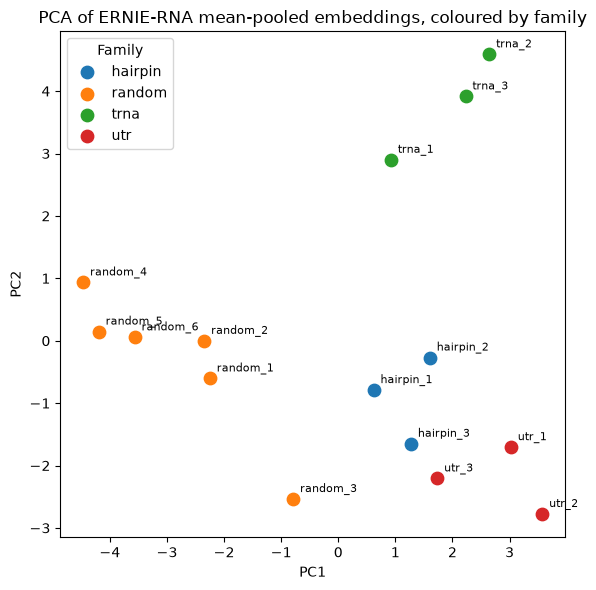

In [31]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(mean_matrix)

families = [sequence_family[n] for n in names]
unique_families = sorted(set(families))
cmap = plt.get_cmap("tab10")
family_colors = {fam: cmap(i) for i, fam in enumerate(unique_families)}

plt.figure(figsize=(6, 6))
for fam in unique_families:
    idx = [i for i, f in enumerate(families) if f == fam]
    plt.scatter(coords[idx, 0], coords[idx, 1], color=family_colors[fam], label=fam, s=80)
for i, n in enumerate(names):
    plt.annotate(n, (coords[i, 0], coords[i, 1]), textcoords="offset points", xytext=(5, 5), fontsize=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of ERNIE-RNA mean-pooled embeddings, coloured by family")
plt.legend(title="Family")
plt.tight_layout()
plt.show()

<span style="color:red"> 

## EXERCISE 2: Using real data, reproduce the family-coloured visualisation 

1. Load the provided real data for three families of RNA: IRIS, miRNA, and snoRNA from the provided files. 
2. Calculate the sequence embeddings. 
3. Visualise the embeddings in a plot as per the above. 

</span>

In [ ]:
# TODO

In [ ]:
# TODO

In [ ]:
# TODO

<span style="color:red"> 

## EXERCISE 3: Family prediction from embedding

1. Create a predictive model that is able to predict family membership from sequence embeddings. 
2. Train your model using the provided data for the three families. 
3. How well does your model perform? 
4. Make predictions for the additional test data for which you do not know what the correct family is. Which family do you think each sequence belongs to? 

</span>

<span style="color:red"> 

## Bonus task 1: Do the structures look as you would expect?

How would you explore the secondary structures of the sequences to make sure they have the structure you expect?

Hint: Use ViennaRNA package

</span>

<span style="color:red"> 

## Bonus task 2: Which embedding of the three different ones gives a better predictive model? 

## Bonus task 3: How robust is your predictive performance to different starting seeds? 

</span>